# Customer Churn Prediction

## Objective
Predict which customers are likely to churn using machine learning.

## Dataset
IBM Telco Customer Churn Dataset

## Tools Used
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn
- XGBoost

In [8]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

%matplotlib inline

## Load Dataset

In [9]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Data Understanding

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [11]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [12]:
    df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [13]:
df.duplicated().sum()

0

## Data Cleaning

In [14]:
df_clean = df.copy()

In [15]:
df_clean["TotalCharges"] = pd.to_numeric(
    df_clean["TotalCharges"],
    errors="coerce"
)

df_clean.dropna(inplace=True)

In [16]:
df_clean.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [17]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   object 
 1   gender            7032 non-null   object 
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   object 
 4   Dependents        7032 non-null   object 
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   object 
 7   MultipleLines     7032 non-null   object 
 8   InternetService   7032 non-null   object 
 9   OnlineSecurity    7032 non-null   object 
 10  OnlineBackup      7032 non-null   object 
 11  DeviceProtection  7032 non-null   object 
 12  TechSupport       7032 non-null   object 
 13  StreamingTV       7032 non-null   object 
 14  StreamingMovies   7032 non-null   object 
 15  Contract          7032 non-null   object 
 16  PaperlessBilling  7032 non-null   object 
 17  

In [18]:
df_clean.to_csv("cleaned_customer_churn.csv", index=False)

In [19]:
import os

print(os.getcwd())

C:\Users\Anmol\Datap


# Exploratory Data Analysis (EDA)

### 1. Churn Distribution

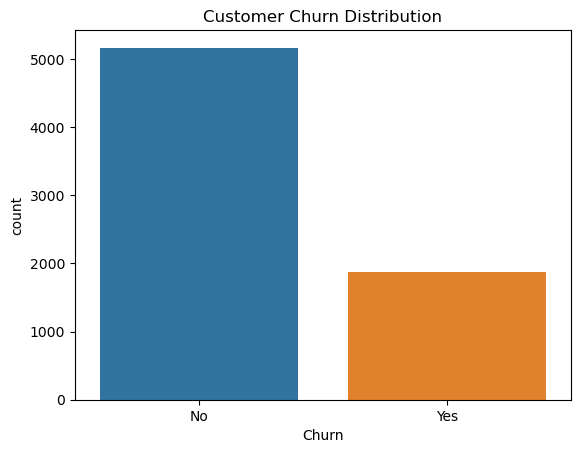

In [20]:
sns.countplot(x="Churn", data=df_clean)
plt.title("Customer Churn Distribution")
plt.show()

Observation:
Most customers have not churned. The dataset is slightly imbalanced.

### 2. Gender vs Churn

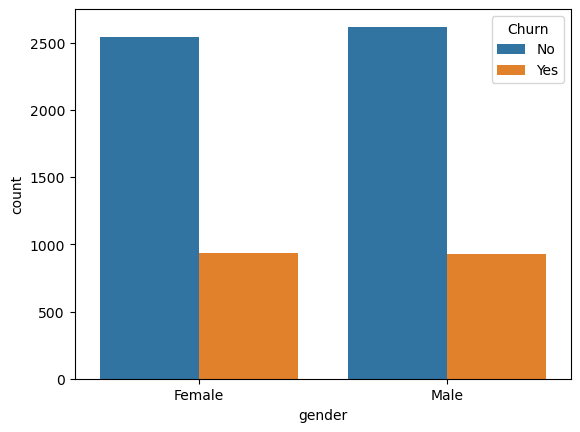

In [75]:
sns.countplot(x="gender", hue="Churn", data=df_clean)
plt.savefig("images/gender vs churn.png", dpi=300, bbox_inches="tight")

plt.show()

Observation:
Male and female customers show similar churn behavior.

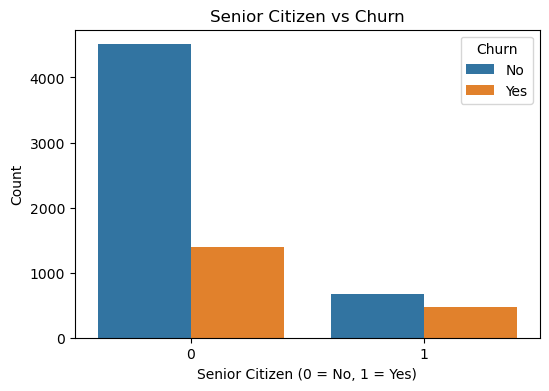

In [76]:
plt.figure(figsize=(6,4))
sns.countplot(x='SeniorCitizen', hue='Churn', data=df)
plt.title('Senior Citizen vs Churn')
plt.xlabel('Senior Citizen (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.savefig("images/senior citizen vs churn.png", dpi=300, bbox_inches="tight")

plt.show()

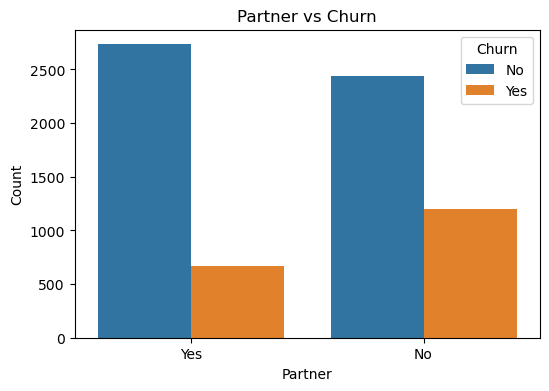

In [77]:
plt.figure(figsize=(6,4))
sns.countplot(x='Partner', hue='Churn', data=df)
plt.title('Partner vs Churn')
plt.xlabel('Partner')
plt.ylabel('Count')
plt.savefig("images/partner vs churn.png", dpi=300, bbox_inches="tight")

plt.show()

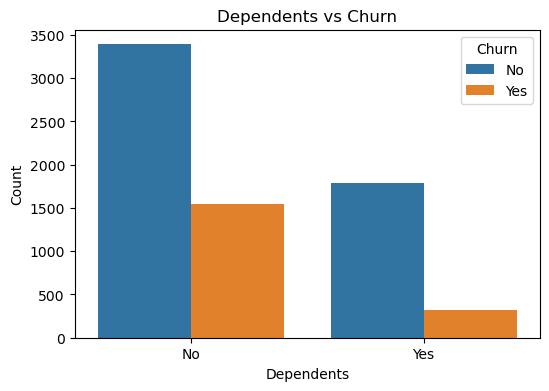

In [78]:
plt.figure(figsize=(6,4))
sns.countplot(x='Dependents', hue='Churn', data=df)
plt.title('Dependents vs Churn')
plt.xlabel('Dependents')
plt.ylabel('Count')
plt.savefig("images/dependent vs churn.png", dpi=300, bbox_inches="tight")
plt.show()

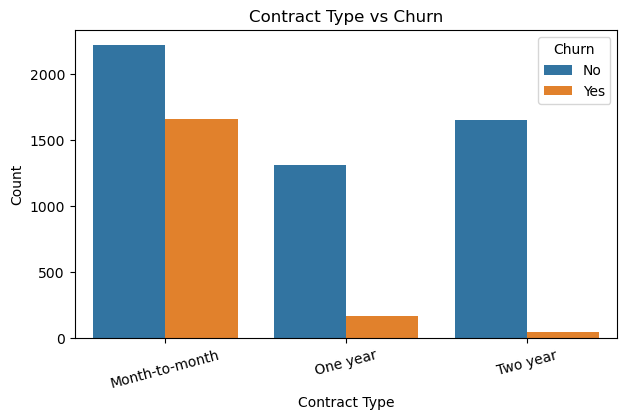

In [79]:
plt.figure(figsize=(7,4))
sns.countplot(x='Contract', hue='Churn', data=df)
plt.title('Contract Type vs Churn')
plt.xlabel('Contract Type')
plt.ylabel('Count')
plt.xticks(rotation=15)
plt.savefig("images/contract type vs churn.png", dpi=300, bbox_inches="tight")
plt.show()

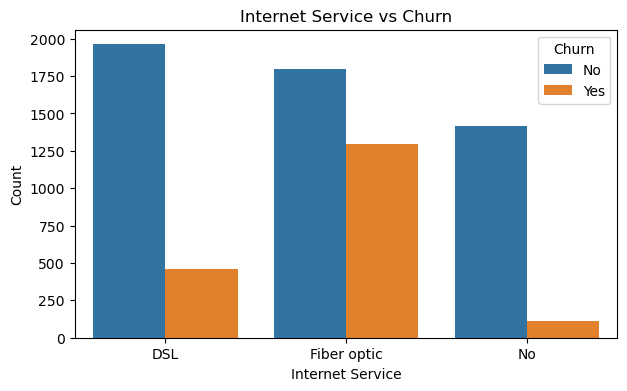

In [80]:
plt.figure(figsize=(7,4))
sns.countplot(x='InternetService', hue='Churn', data=df)
plt.title('Internet Service vs Churn')
plt.xlabel('Internet Service')
plt.ylabel('Count')
plt.savefig("images/internet service vs churn.png", dpi=300, bbox_inches="tight")
plt.show()

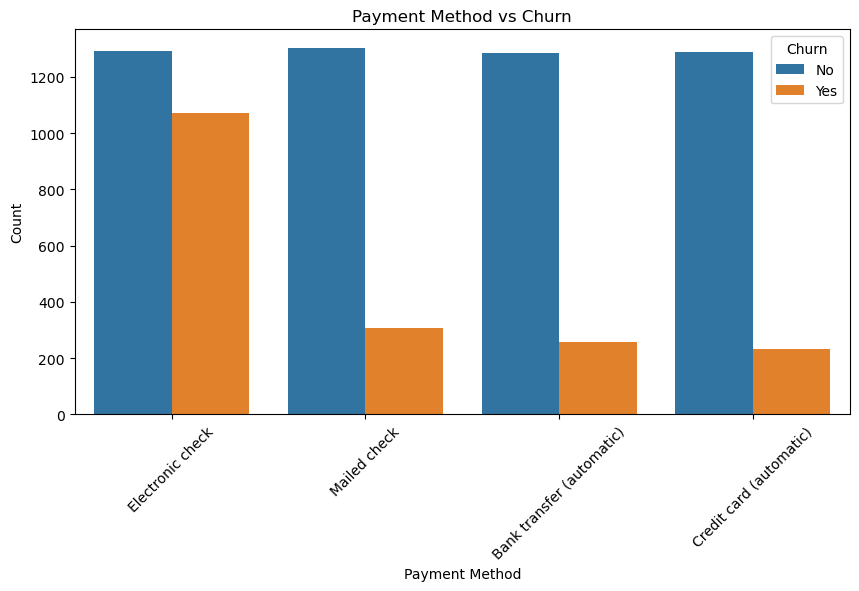

In [81]:
plt.figure(figsize=(10,5))
sns.countplot(x='PaymentMethod', hue='Churn', data=df)
plt.title('Payment Method vs Churn')
plt.xlabel('Payment Method')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.savefig("images/payment method vs churn.png", dpi=300, bbox_inches="tight")
plt.show()

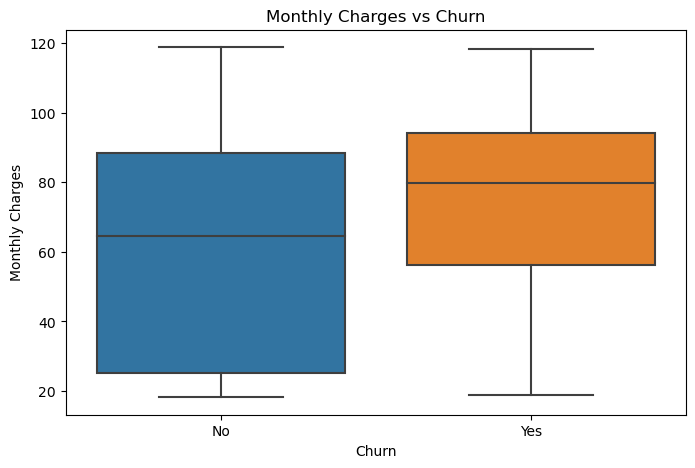

In [82]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.title('Monthly Charges vs Churn')
plt.xlabel('Churn')
plt.ylabel('Monthly Charges')
plt.savefig("images/monthly charges vs churn.png", dpi=300, bbox_inches="tight")
plt.show()

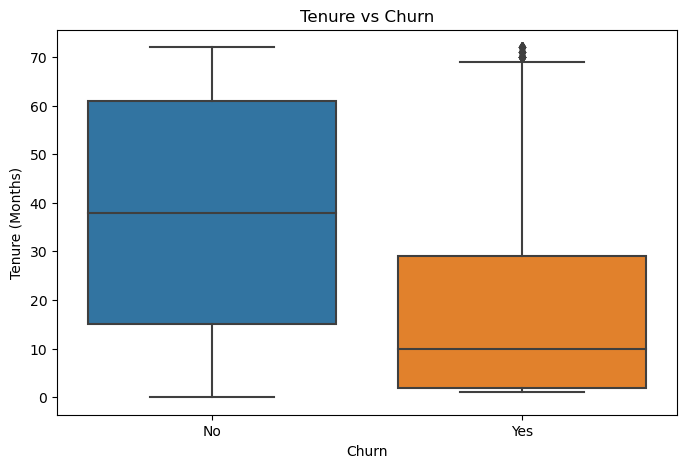

In [83]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Churn', y='tenure', data=df)
plt.title('Tenure vs Churn')
plt.xlabel('Churn')
plt.ylabel('Tenure (Months)')
plt.savefig("images/Tenure vs churn.png", dpi=300, bbox_inches="tight")
plt.show()

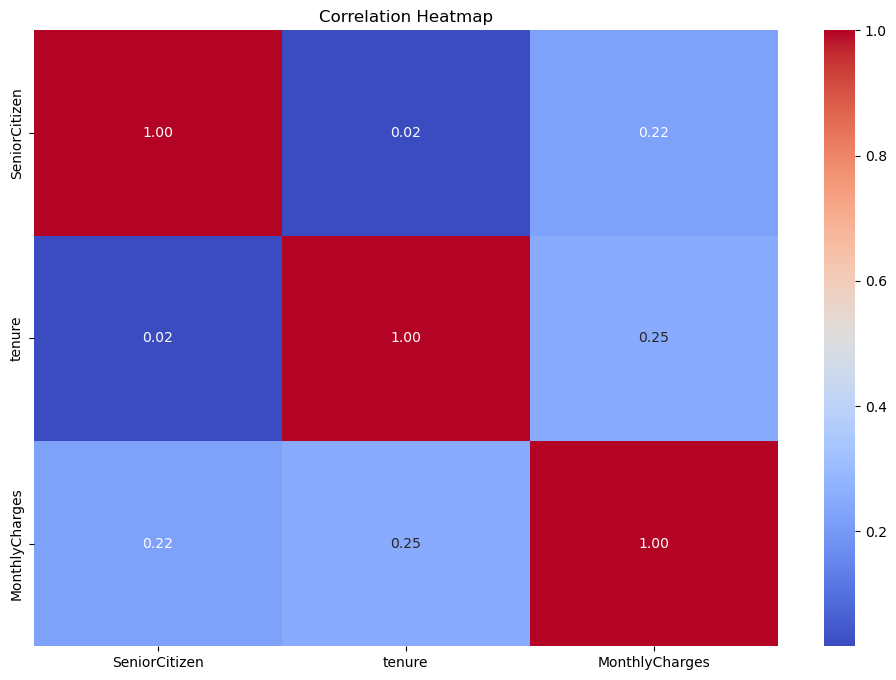

In [84]:
plt.figure(figsize=(12,8))

numeric_df = df.select_dtypes(include=['int64', 'float64'])

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap')
plt.savefig("images/correlation heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

# Data Preprocessing

In [31]:
from sklearn.preprocessing import LabelEncoder

# Create a copy of the cleaned dataset
df_encoded = df_clean.copy()

# Initialize LabelEncoder
le = LabelEncoder()

# Encode all categorical columns
for column in df_encoded.columns:
    if df_encoded[column].dtype == 'object':
        df_encoded[column] = le.fit_transform(df_encoded[column])

# Display first 5 rows
df_encoded.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,5365,0,0,1,0,1,0,1,0,0,...,0,0,0,0,0,1,2,29.85,29.85,0
1,3953,1,0,0,0,34,1,0,0,2,...,2,0,0,0,1,0,3,56.95,1889.50,0
2,2558,1,0,0,0,2,1,0,0,2,...,0,0,0,0,0,1,3,53.85,108.15,1
3,5524,1,0,0,0,45,0,1,0,2,...,2,2,0,0,1,0,0,42.30,1840.75,0
4,6500,0,0,0,0,2,1,0,1,0,...,0,0,0,0,0,1,2,70.70,151.65,1


In [32]:
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   int32  
 1   gender            7032 non-null   int32  
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   int32  
 4   Dependents        7032 non-null   int32  
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   int32  
 7   MultipleLines     7032 non-null   int32  
 8   InternetService   7032 non-null   int32  
 9   OnlineSecurity    7032 non-null   int32  
 10  OnlineBackup      7032 non-null   int32  
 11  DeviceProtection  7032 non-null   int32  
 12  TechSupport       7032 non-null   int32  
 13  StreamingTV       7032 non-null   int32  
 14  StreamingMovies   7032 non-null   int32  
 15  Contract          7032 non-null   int32  
 16  PaperlessBilling  7032 non-null   int32  
 17  

In [33]:
# Features
X = df_encoded.drop("Churn", axis=1)

# Target
y = df_encoded["Churn"]

In [34]:
print("X Shape:", X.shape)
print("y Shape:", y.shape)

X Shape: (7032, 20)
y Shape: (7032,)


In [35]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [36]:
print("Training Data:", X_train.shape)
print("Testing Data :", X_test.shape)

Training Data: (5625, 20)
Testing Data : (1407, 20)


In [37]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Scale the training data
X_train_scaled = scaler.fit_transform(X_train)

# Scale the testing data
X_test_scaled = scaler.transform(X_test)

In [38]:
print(X_train_scaled.shape)
print(X_test_scaled.shape)

(5625, 20)
(1407, 20)


# Logistic Regression

In [39]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

In [40]:
# Create the model
lr_model = LogisticRegression(random_state=42)

# Train the model
lr_model.fit(X_train_scaled, y_train)

LogisticRegression(random_state=42)

In [41]:
# Predict labels
y_pred_lr = lr_model.predict(X_test_scaled)

# Predict probabilities
y_prob_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

In [42]:
print("Accuracy :", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall   :", recall_score(y_test, y_pred_lr))
print("F1 Score :", f1_score(y_test, y_pred_lr))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_lr))

Accuracy : 0.7938877043354655
Precision: 0.6265060240963856
Recall   : 0.5561497326203209
F1 Score : 0.5892351274787535
ROC-AUC  : 0.8342349524514548


In [43]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.85      0.88      0.86      1033
           1       0.63      0.56      0.59       374

    accuracy                           0.79      1407
   macro avg       0.74      0.72      0.73      1407
weighted avg       0.79      0.79      0.79      1407



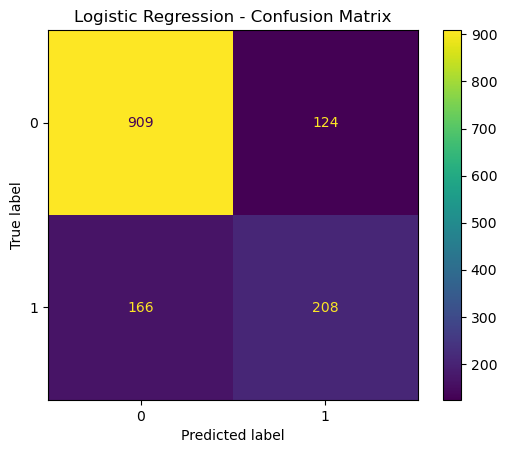

In [85]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lr)
plt.title("Logistic Regression - Confusion Matrix")
plt.savefig("images/LR confusion matrix.png", dpi=300, bbox_inches="tight")
plt.show()

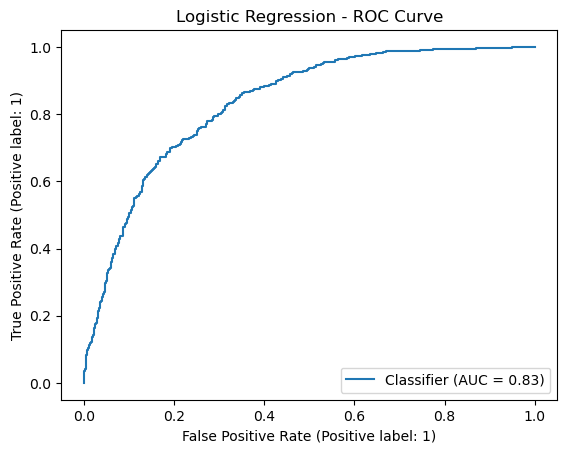

In [87]:
RocCurveDisplay.from_predictions(y_test, y_prob_lr)
plt.title("Logistic Regression - ROC Curve")
plt.savefig("images/LR ROC curve.png", dpi=300, bbox_inches="tight")
plt.show()

# Random Forest

In [46]:
from sklearn.ensemble import RandomForestClassifier

In [47]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [48]:
y_pred_rf = rf_model.predict(X_test)

y_prob_rf = rf_model.predict_proba(X_test)[:,1]

In [49]:
print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("F1 Score :", f1_score(y_test, y_pred_rf))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_rf))

Accuracy : 0.7846481876332623
Precision: 0.6203389830508474
Recall   : 0.4893048128342246
F1 Score : 0.547085201793722
ROC-AUC  : 0.8242114499588448


In [50]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.62      0.49      0.55       374

    accuracy                           0.78      1407
   macro avg       0.72      0.69      0.70      1407
weighted avg       0.77      0.78      0.78      1407



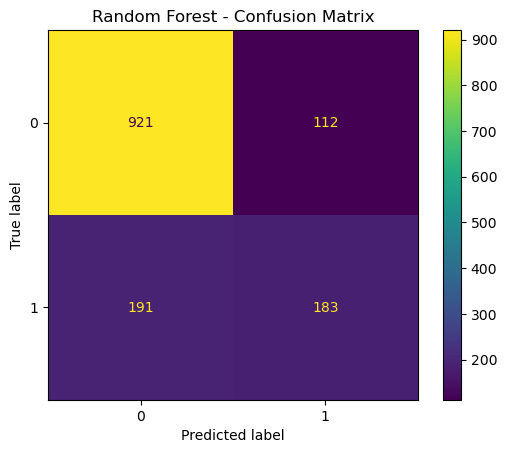

In [88]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf)
plt.title("Random Forest - Confusion Matrix")
plt.savefig("images/RM confusion matrix.png", dpi=300, bbox_inches="tight")
plt.show()

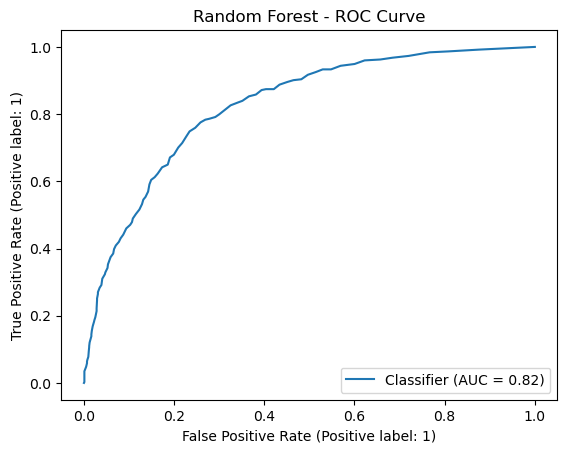

In [89]:
RocCurveDisplay.from_predictions(y_test, y_prob_rf)
plt.title("Random Forest - ROC Curve")
plt.savefig("images/RM roc curve.png", dpi=300, bbox_inches="tight")
plt.show()

# XGBoost

In [53]:
pip install xgboost

In [54]:
from xgboost import XGBClassifier

In [55]:
xgb_model = XGBClassifier(
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [56]:
y_pred_xgb = xgb_model.predict(X_test)

y_prob_xgb = xgb_model.predict_proba(X_test)[:,1]

In [57]:
print("Accuracy :", accuracy_score(y_test, y_pred_xgb))
print("Precision:", precision_score(y_test, y_pred_xgb))
print("Recall   :", recall_score(y_test, y_pred_xgb))
print("F1 Score :", f1_score(y_test, y_pred_xgb))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_xgb))

Accuracy : 0.7839374555792467
Precision: 0.6067073170731707
Recall   : 0.5320855614973262
F1 Score : 0.566951566951567
ROC-AUC  : 0.8165459618679825


In [58]:
print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.84      0.88      0.86      1033
           1       0.61      0.53      0.57       374

    accuracy                           0.78      1407
   macro avg       0.72      0.70      0.71      1407
weighted avg       0.78      0.78      0.78      1407



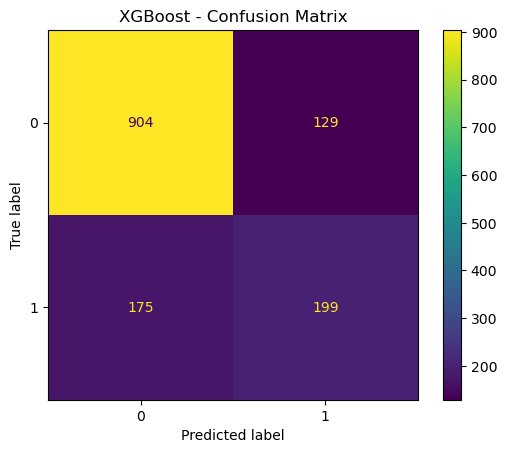

In [90]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_xgb)
plt.title("XGBoost - Confusion Matrix")
plt.savefig("images/xgboost CM.png", dpi=300, bbox_inches="tight")
plt.show()

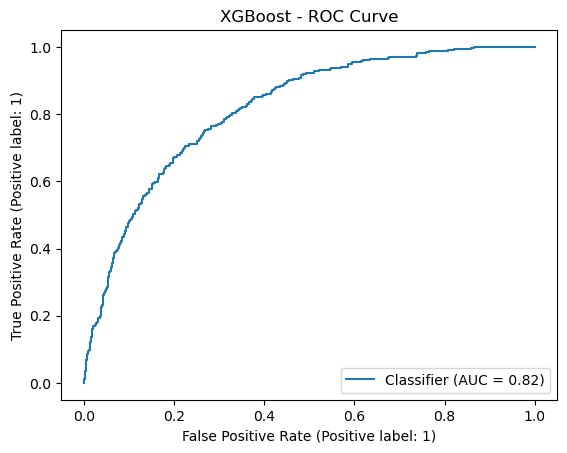

In [91]:
RocCurveDisplay.from_predictions(y_test, y_prob_xgb)
plt.title("XGBoost - ROC Curve")
plt.savefig("images/XGboost RC.png", dpi=300, bbox_inches="tight")
plt.show()

# Model Evaluation

In [61]:
# Create a comparison table
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "XGBoost"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_xgb)
    ],
    "Precision": [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_xgb)
    ],
    "Recall": [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_xgb)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_prob_lr),
        roc_auc_score(y_test, y_prob_rf),
        roc_auc_score(y_test, y_prob_xgb)
    ]
})

results = results.sort_values(by="ROC-AUC", ascending=False)

results

,Model,Accuracy,Precision,Recall,ROC-AUC
0,Logistic Regression,0.793888,0.626506,0.556150,0.834235
1,Random Forest,0.784648,0.620339,0.489305,0.824211
2,XGBoost,0.783937,0.606707,0.532086,0.816546


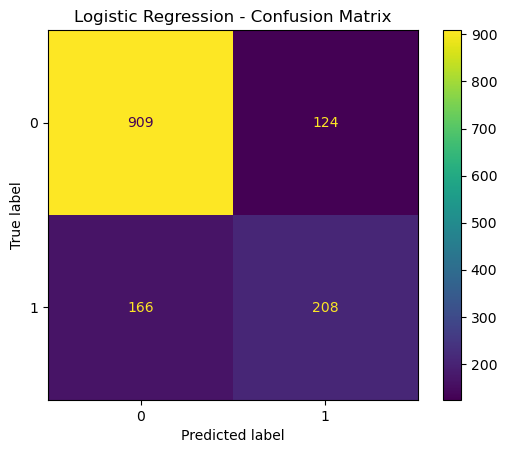

In [62]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lr)
plt.title("Logistic Regression - Confusion Matrix")
plt.show()

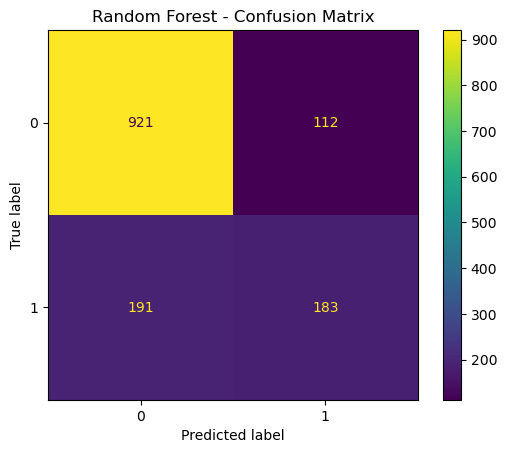

In [63]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf)
plt.title("Random Forest - Confusion Matrix")
plt.show()

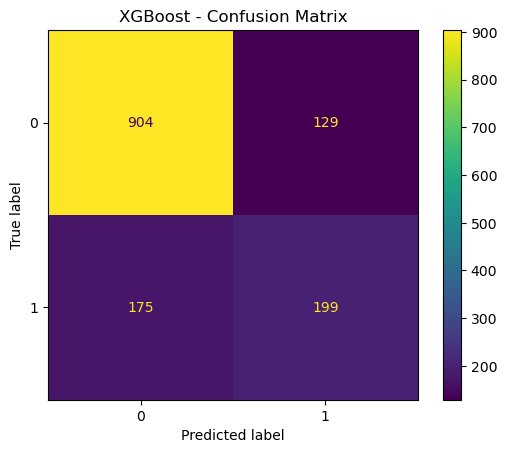

In [64]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_xgb)
plt.title("XGBoost - Confusion Matrix")
plt.show()

<Figure size 800x600 with 0 Axes>

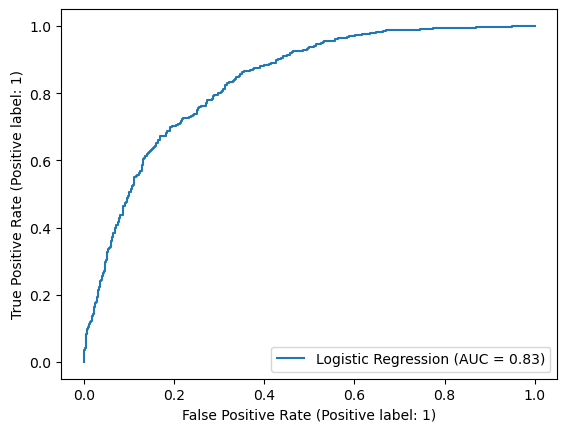

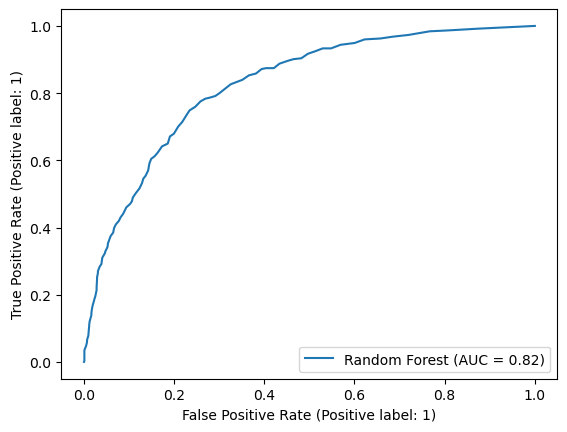

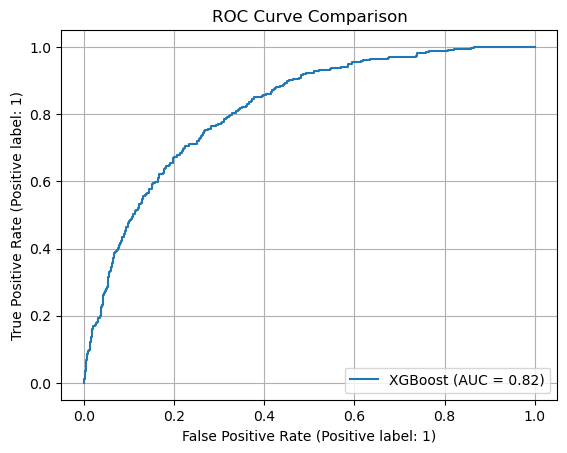

In [65]:
from sklearn.metrics import RocCurveDisplay

plt.figure(figsize=(8,6))

RocCurveDisplay.from_predictions(
    y_test,
    y_prob_lr,
    name="Logistic Regression"
)

RocCurveDisplay.from_predictions(
    y_test,
    y_prob_rf,
    name="Random Forest"
)

RocCurveDisplay.from_predictions(
    y_test,
    y_prob_xgb,
    name="XGBoost"
)

plt.title("ROC Curve Comparison")
plt.grid(True)
plt.show()

In [66]:
best_model = results.iloc[0]

print("Best Model:", best_model["Model"])
print("Accuracy :", round(best_model["Accuracy"], 4))
print("Precision:", round(best_model["Precision"], 4))
print("Recall   :", round(best_model["Recall"], 4))
print("ROC-AUC  :", round(best_model["ROC-AUC"], 4))

Best Model: Logistic Regression
Accuracy : 0.7939
Precision: 0.6265
Recall   : 0.5561
ROC-AUC  : 0.8342


In [68]:
import joblib

joblib.dump(rf_model, "best_model.pkl")

['best_model.pkl']

# Business Conclusion

## Key Findings

* The overall churn rate indicates that a significant portion of customers discontinue the service, highlighting the need for effective customer retention strategies.
* Customers with **month-to-month contracts** have the highest churn rate compared to those with one-year or two-year contracts.
* Customers with **higher monthly charges** are more likely to churn than customers with lower monthly charges.
* Contract type, tenure, monthly charges, internet service, and payment method are among the most influential factors affecting customer churn.
* Among the evaluated classification models, **Random Forest** achieved the highest ROC-AUC score, making it the best-performing model for predicting customer churn in this project.

## Recommendations

* Encourage customers to switch from month-to-month plans to long-term contracts by offering discounts or exclusive benefits.
* Identify high-risk customers using the prediction model and implement proactive retention strategies such as personalized offers, discounts, or customer support.
* Provide loyalty rewards for long-term customers to improve retention.
* Review pricing strategies for customers with high monthly charges and introduce value-added plans to reduce churn.
* Continuously monitor churn trends and retrain the prediction model periodically to maintain prediction accuracy.

## Conclusion

This project successfully developed a customer churn prediction model using Logistic Regression, Random Forest, and XGBoost. After evaluating the models using Accuracy, Recall, and ROC-AUC, the Random Forest model demonstrated the best overall performance. The insights obtained from Exploratory Data Analysis (EDA) and machine learning can help businesses identify customers at risk of churning and implement targeted retention strategies to improve customer satisfaction and reduce revenue loss.


In [92]:
with open(".gitignore", "w") as f:
    f.write("""__pycache__/
.ipynb_checkpoints/
*.pyc
""")

print(".gitignore created successfully!")

.gitignore created successfully!
